In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("/kaggle/input/data-nmt-2-all3/data_nmt_2_all3.csv")

In [6]:
df = df.drop(columns=["reviewer", "reviewer_notes"])

In [7]:
df.head()

,group_id,sentence_id,source_sentence,translator,human_translations,subject_pronouns,pronoun_labels,model1,model2,model3,translategemma-4b,sentence_index,coreference,llama3.1-IT-8B
0,1,1,Maria said that she would arrive early.,Translator2,Maria erken geleceğini söyledi,['she'],[0],Maria erken geleceğini söylemişti.,Meryem erken geldiğini söyledi.,Maria erken geleceğini söyledi.,"Maria, erken geleceğimi söyledim.",1,1,Maria erken gelecek.
1,1,2,Maria said that he would arrive early.,Translator2,Maria onun erken geleceğini söyledi.,['he'],[1],Maria erken geleceğini söylemişti.,Meryem erken geldiğini söyledi.,Maria onun erken geleceğini söyledi.,"Maria, erken geleceğini söyledi.",2,0,"Maria, erkenden geleceğini söyledi."
2,2,3,David believed that he could solve the problem.,Translator1,David sorunu çözebileceğine inandı.,['he'],[0],David sorunu çözebileceğine inanıyordu.,David bu sorunun çözülebileceğine inanıyordu.,David sorunu çözebileceğine inanıyordu.,"David, bu problemi çözebileceğine inanıyordu.",1,1,"David, problemi çözebileceğini düşündü."
3,2,4,David believed that she could solve the problem.,Translator1,"David, onun sorunu çözebileceğine inandı.",['she'],[1],David onun sorunu çözebileceğine inanıyordu.,David bu sorunun çözülebileceğine inanıyordu.,"David, sorunu çözebileceğine inanıyordu.","David, bu sorunu çözebileceğine inanıyordu.",2,0,"David, onun problemi çözebileceğini düşünüyordu."
4,3,5,Anna hoped that she would win the prize.,Translator2,Anna ödülü kazanacağını umuyordu.,['she'],[0],Anna ödülü kazanmayı umuyordu.,Anna ödülü kazanacağını umuyordu.,Anna ödülü kazanmayı umuyordu.,"Anna, ödülü kazanacağını umuyordu.",1,1,"Anna, ödülü kazanacağı umudu içindeydi."


In [8]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.5 MB/s eta 0:00:0000:0100:01


In [9]:
import stanza
stanza.download("tr")

2026-02-10 10:15:51 INFO: Downloaded file to /root/stanza_resources/resources.json
2026-02-10 10:15:51 INFO: Downloading default packages for language: tr (Turkish) ...


2026-02-10 10:15:55 INFO: Downloaded file to /root/stanza_resources/tr/default.zip
2026-02-10 10:15:58 INFO: Finished downloading models and saved to /root/stanza_resources


In [10]:
nlp = stanza.Pipeline("tr", processors="tokenize,pos,mwt,lemma,depparse")

2026-02-10 10:15:58 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-02-10 10:15:58 INFO: Downloaded file to /root/stanza_resources/resources.json
2026-02-10 10:15:59 INFO: Loading these models for language: tr (Turkish):
| Processor | Package       |
-----------------------------
| tokenize  | imst          |
| mwt       | imst          |
| pos       | imst_charlm   |
| lemma     | imst_nocharlm |
| depparse  | imst_charlm   |

2026-02-10 10:15:59 INFO: Using device: cuda
2026-02-10 10:15:59 INFO: Loading: tokenize
2026-02-10 10:16:02 INFO: Loading: mwt
2026-02-10 10:16:02 INFO: Loading: pos
2026-02-10 10:16:04 INFO: Loading: lemma
2026-02-10 10:16:04 INFO: Loading: depparse
2026-02-10 10:16:05 INFO: Done loading processors!


In [11]:
def contains_onun(text):
    """Annotates data if there is "onun" in the output sentence by writing True or False"""
    if not isinstance(text, str):
        return False

    doc = nlp(text)
    for sent in doc.sentences:
        for word in sent.words:
            
            # must be subject
            #if word.deprel != "nsubj": (doesn't count some of "onun")
             #   continue
                
            if word.upos == "PRON" and word.feats:
                feats = word.feats.split("|")
                if "Case=Gen" in feats and "Person=3" in feats and "PronType=Prs" in feats and not any("Reflex=Yes" in f for f in feats): #reflex=yes corresponds "kendisini" in Turkish
                    return True
    return False

In [12]:
df = df.rename(columns={
    "model1": "opus-tatoeba-en-tr",
    "model2": "m2m100-418M",
    "model3": "NLLB200-3.3B"
})
model_cols = ["human_translations", "opus-tatoeba-en-tr", "m2m100-418M", "NLLB200-3.3B", "translategemma-4b", "llama3.1-IT-8B"]

for col in model_cols:
    df[f"{col}_has_onun"] = df[col].apply(contains_onun)

In [13]:
df.head(52)
df.columns

Index(['group_id', 'sentence_id', 'source_sentence', 'translator',
       'human_translations', 'subject_pronouns', 'pronoun_labels',
       'opus-tatoeba-en-tr', 'm2m100-418M', 'NLLB200-3.3B',
       'translategemma-4b', 'sentence_index', 'coreference', 'llama3.1-IT-8B',
       'human_translations_has_onun', 'opus-tatoeba-en-tr_has_onun',
       'm2m100-418M_has_onun', 'NLLB200-3.3B_has_onun',
       'translategemma-4b_has_onun', 'llama3.1-IT-8B_has_onun'],
      dtype='object')

In [14]:
df.to_csv("data2_nmt_analysis.csv", index=False)

In [15]:
mismatch_df = df[df['coreference'] == 0]

In [16]:
data_cols = ["human_translations_has_onun", "opus-tatoeba-en-tr_has_onun", "m2m100-418M_has_onun", "NLLB200-3.3B_has_onun", "translategemma-4b_has_onun", "llama3.1-IT-8B_has_onun"]

for col in data_cols:
    count = mismatch_df[col].sum()
    total = len(mismatch_df)
    rate = count / total * 100
    print(f"{col}: {count}/{total} → {rate:.2f}%")

human_translations_has_onun: 96/96 → 100.00%
opus-tatoeba-en-tr_has_onun: 8/96 → 8.33%
m2m100-418M_has_onun: 1/96 → 1.04%
NLLB200-3.3B_has_onun: 20/96 → 20.83%
translategemma-4b_has_onun: 29/96 → 30.21%
llama3.1-IT-8B_has_onun: 5/96 → 5.21%


In [17]:
match_df = df[df['coreference'] == 1]

In [18]:
for col in data_cols:
    count = match_df[col].sum()
    total = len(match_df)
    rate = count / total * 100
    print(f"{col}: {count}/{total} → {rate:.2f}%")

human_translations_has_onun: 0/96 → 0.00%
opus-tatoeba-en-tr_has_onun: 0/96 → 0.00%
m2m100-418M_has_onun: 0/96 → 0.00%
NLLB200-3.3B_has_onun: 0/96 → 0.00%
translategemma-4b_has_onun: 0/96 → 0.00%
llama3.1-IT-8B_has_onun: 0/96 → 0.00%


In [19]:
def onun_rate(df, coref_value=0):
    mismatch_df = df[df['coreference'] == coref_value]
    data_cols = [col for col in df.columns if col.endswith("_has_onun")]

    for col in data_cols:
        count = mismatch_df[col].sum()
        total = len(mismatch_df)
        rate = count / total * 100 if total > 0 else 0
        print(f"{col}: {count}/{total} → {rate:.2f}%")

In [20]:
onun_rate(df, coref_value=0)  # non-coreferential

human_translations_has_onun: 96/96 → 100.00%
opus-tatoeba-en-tr_has_onun: 8/96 → 8.33%
m2m100-418M_has_onun: 1/96 → 1.04%
NLLB200-3.3B_has_onun: 20/96 → 20.83%
translategemma-4b_has_onun: 29/96 → 30.21%
llama3.1-IT-8B_has_onun: 5/96 → 5.21%


In [21]:
onun_rate(df, coref_value=1)  # coreferential (check if any model generates "onun" when matched )

human_translations_has_onun: 0/96 → 0.00%
opus-tatoeba-en-tr_has_onun: 0/96 → 0.00%
m2m100-418M_has_onun: 0/96 → 0.00%
NLLB200-3.3B_has_onun: 0/96 → 0.00%
translategemma-4b_has_onun: 0/96 → 0.00%
llama3.1-IT-8B_has_onun: 0/96 → 0.00%


In [22]:
results = []
for col in data_cols:
    count = mismatch_df[col].sum()
    total = len(mismatch_df)
    rate = count / total * 100
    results.append({
        "Model": col,
        "Onun Count": count,
        "Total": total,
        "Onun Rate(%)": rate
    })

results_df = pd.DataFrame(results)
results_df

,Model,Onun Count,Total,Onun Rate(%)
0,human_translations_has_onun,96,96,100.000000
1,opus-tatoeba-en-tr_has_onun,8,96,8.333333
2,m2m100-418M_has_onun,1,96,1.041667
3,NLLB200-3.3B_has_onun,20,96,20.833333
4,translategemma-4b_has_onun,29,96,30.208333
5,llama3.1-IT-8B_has_onun,5,96,5.208333


In [23]:
results = []

for col in data_cols:
    onun_sentences = []  # list to store sentences with 'onun'

    for _, row in mismatch_df.iterrows():
        if row[col]:  # this sentence has 'onun'
            tgt = row[col.replace("_has_onun", "")]  # actual translation
            src = row["source_sentence"]
            onun_sentences.append({"source": src, "target": tgt})

    count = len(onun_sentences)
    total = len(mismatch_df)
    rate = count / total * 100 if total > 0 else 0

    results.append({
        "Model": col,
        "Onun_count": count,
        "Total": total,
        "Onun_rate(%)": rate,
        "Sentences": onun_sentences  # store the actual sentences
    })

results_df = pd.DataFrame(results)
results_df.head()

,Model,Onun_count,Total,Onun_rate(%),Sentences
0,human_translations_has_onun,96,96,100.000000,[{'source': 'Maria said that he would arrive e...
1,opus-tatoeba-en-tr_has_onun,8,96,8.333333,[{'source': 'David believed that she could sol...
2,m2m100-418M_has_onun,1,96,1.041667,[{'source': 'She whispered that he was feeling...
3,NLLB200-3.3B_has_onun,20,96,20.833333,[{'source': 'Maria said that he would arrive e...
4,translategemma-4b_has_onun,29,96,30.208333,[{'source': 'Anna hoped that he would win the ...


## See the all subject pronouns used instead of "o" and "onun".

In [24]:
def annotate_onun_only(text):
    if contains_onun(text):
        return "onun", '"1"'
    else:
        return "-", '"0"'

In [25]:
for col_name in model_cols:
    subj_col = f"subject_pronouns_{col_name}"
    label_col = f"pronoun_labels_{col_name}"

    # Create columns first otherwise raise an error.
    df[subj_col] = ""
    df[label_col] = ""
    
    # Apply the annotation to first 103 sentences
    results = df.loc[:102, col_name].apply(annotate_onun_only)
    df.loc[:102, subj_col] = results.apply(lambda x: x[0])
    df.loc[:102, label_col] = results.apply(lambda x: x[1])

In [26]:
def annotate_all_subjects(text):
    """
    Annotate the subjects in a sentence, including both main and genitive subjects.
    1. Main subject:
       - Finds the first nominal subject (nsubj) in the sentence
       - Excludes passive voice or genitive case
       - Includes nouns or pronouns in nominative, active voice
    2. Genitive subject (onun-like):
       - Finds the first noun or pronoun marked with genitive case
       - Includes pronouns like 'onun' or genitive nouns
    Returns:
    - pronouns: a list of two elements
        [main_subject (or '-' if missing), genitive_subject (or '-' if missing)]
    - labels: a corresponding list of two elements
        [1 if main_subject exists else 0, 1 if genitive_subject exists else 0]
    """
    if not isinstance(text, str):
        return "-,-", "0,0"

    main_subject = "-"
    genitive_subject = "-"

    doc = nlp(text.lower())
    for sent in doc.sentences:
        for word in sent.words:
            # main subject
            if word.deprel == "nsubj":
                if word.feats and ("Voice=Pass" in word.feats or "Case=Gen" in word.feats):
                    continue
                if word.upos in ["PRON", "NOUN"]:
                    main_subject = word.text
                    break
        # genitive subject (onun-like)
        for word in sent.words:
            if word.feats and "Case=Gen" in word.feats:
                if word.upos in ["PRON", "NOUN"]:
                    genitive_subject = word.text
                    break
        if main_subject and genitive_subject:
            break
    # labels
    main_label = 1 if main_subject != "-" else 0
    gen_label = 1 if genitive_subject != "-" else 0

    pronouns = f"{main_subject},{genitive_subject}"
    labels = f'"{main_label},{gen_label}"'

    return pronouns, labels

In [27]:
for col_name in model_cols:
    subj_col = f"subject_pronouns_{col_name}"
    label_col = f"pronoun_labels_{col_name}"

    # Apply annotation to sentences after 102 (index 102 onward)
    results = df.loc[102:, col_name].apply(annotate_all_subjects)
    df.loc[102:, subj_col] = results.apply(lambda x: x[0])
    df.loc[102:, label_col] = results.apply(lambda x: x[1])

In [28]:
df.head(105)
df.to_csv("data2_nmt_analysis_detailed.csv", index=False) #this file must be manually fixed then get statistics

After manually correcting

----------------

In [29]:
import pandas as pd

In [36]:
df = pd.read_csv("/kaggle/input/datasets/buketsak/data2-nmt-analysis-detailed-corrected/data2_nmt_analysis_detailed_corrected.csv")

In [37]:
model_cols = ["human_translations", "opus-tatoeba-en-tr", "m2m100-418M", "NLLB200-3.3B", "translategemma-4b", "llama3.1-IT-8B"]

In [38]:
for model in model_cols:
    label_col = f"pronoun_labels_{model}"
    df[label_col] = df[label_col].str.strip('"')

In [39]:
df.head(10)

,group_id,sentence_id,source_sentence,translator,human_translations,subject_pronouns,pronoun_labels,opus-tatoeba-en-tr,m2m100-418M,NLLB200-3.3B,...,subject_pronouns_opus-tatoeba-en-tr,pronoun_labels_opus-tatoeba-en-tr,subject_pronouns_m2m100-418M,pronoun_labels_m2m100-418M,subject_pronouns_NLLB200-3.3B,pronoun_labels_NLLB200-3.3B,subject_pronouns_translategemma-4b,pronoun_labels_translategemma-4b,subject_pronouns_llama3.1-IT-8B,pronoun_labels_llama3.1-IT-8B
0,1,1,Maria said that she would arrive early.,Translator2,Maria erken geleceğini söyledi,['she'],[0],Maria erken geleceğini söylemişti.,Meryem erken geldiğini söyledi.,Maria erken geleceğini söyledi.,...,-,0,-,0,-,0,-,0,-,0
1,1,2,Maria said that he would arrive early.,Translator2,Maria onun erken geleceğini söyledi.,['he'],[1],Maria erken geleceğini söylemişti.,Meryem erken geldiğini söyledi.,Maria onun erken geleceğini söyledi.,...,-,0,-,0,onun,1,-,0,-,0
2,2,3,David believed that he could solve the problem.,Translator1,David sorunu çözebileceğine inandı.,['he'],[0],David sorunu çözebileceğine inanıyordu.,David bu sorunun çözülebileceğine inanıyordu.,David sorunu çözebileceğine inanıyordu.,...,-,0,-,0,-,0,-,0,-,0
3,2,4,David believed that she could solve the problem.,Translator1,"David, onun sorunu çözebileceğine inandı.",['she'],[1],David onun sorunu çözebileceğine inanıyordu.,David bu sorunun çözülebileceğine inanıyordu.,"David, sorunu çözebileceğine inanıyordu.",...,onun,1,-,0,-,0,-,0,onun,1
4,3,5,Anna hoped that she would win the prize.,Translator2,Anna ödülü kazanacağını umuyordu.,['she'],[0],Anna ödülü kazanmayı umuyordu.,Anna ödülü kazanacağını umuyordu.,Anna ödülü kazanmayı umuyordu.,...,-,0,-,0,-,0,-,0,-,0
5,3,6,Anna hoped that he would win the prize.,Translator2,Anna onun ödülü kazanacağını umuyordu.,['he'],[1],Anna ödülü onun kazanmasını umuyordu.,Anna ödülü kazanacağını umuyordu.,Anna ödülü onun kazanacağını umuyordu.,...,onun,1,-,0,onun,1,onun,1,-,0
6,4,7,Olivia thought that she deserved another chance.,Translator2,Olivia başka bir şansı hak ettiğini düşündü.,['she'],[0],Olivia bir şansı daha hak ettiğini düşünüyordu.,Olivia başka bir fırsatı hak ettiğini düşündü.,"Olivia, bir şans daha hak ettiğini düşündü.",...,-,0,-,0,-,0,-,0,-,0
7,4,8,Olivia thought that he deserved another chance.,Translator2,Olivia onun başka bir şansı hak ettiğini düşündü.,['he'],[1],Olivia bir şansı daha hak ettiğini düşünüyordu.,Olivia bir şans daha hak ettiğini düşünüyordu.,Olivia onun bir şans daha hak ettiğini düşündü.,...,-,0,-,0,onun,1,onun,1,-,0
8,5,9,John assumed that he was invited to the meeting.,Translator2,John toplantıya davet edildiğini varsaydı.,['he'],[0],John ibadete davet edildiğini sandı.,"John, toplantıya davet edildiğini kabul etti.","John, toplantıya davet edildiğini sanmıştı.",...,-,0,-,0,-,0,-,0,-,0
9,5,10,John assumed that she was invited to the meeting.,Translator2,John onun toplantıya davet edildiğini varsaydı.,['she'],[1],John onun toplantıya davet edildiğini düşündü.,"John, toplantıya davet edildiğini kabul etti.","John, onun toplantıya davet edildiğini düşündü.",...,onun,1,-,0,onun,1,onun,1,-,0


In [40]:
drop_stats = {}

for model in model_cols:
    subj_col = f"subject_pronouns_{model}"
    label_col = f"pronoun_labels_{model}"
    
    # main sub (first element)
    def get_main_subject_label(cell):
        if isinstance(cell, str) and cell.strip():
            parts = [p.strip() for p in cell.split(",")]
            first = parts[0]
            if first not in ["-", "onun"]:
                return 1
        return 0

    # genitive label
    def get_onun_label(cell):
        if isinstance(cell, str) and cell.strip():
            parts = [p.strip() for p in cell.split(",")]
            if len(parts) == 2:
                return int(parts[1] == "1")
            elif len(parts) == 1:
                return int(parts[0] == "1")
        return 0

    # Main subject labels
    main_subject_labels = df.loc[102:, subj_col].apply(get_main_subject_label)

    # Genitive labels 
    onun_labels = df[label_col].apply(get_onun_label)

    # Counts
    main_subject_kept = (main_subject_labels == 1).sum()
    main_subject_dropped = (main_subject_labels == 0).sum()

    onun_kept = (onun_labels == 1).sum()
    onun_dropped = (onun_labels == 0).sum()

    drop_stats[model] = {
        "Overt main subject": main_subject_kept,
        "Dropped main subject": main_subject_dropped,
        "Overt genitive": onun_kept,
        "Dropped genitive": onun_dropped,
    }

pd.DataFrame(drop_stats).T

,Overt main subject,Dropped main subject,Overt genitive,Dropped genitive
human_translations,2,88,96,96
opus-tatoeba-en-tr,2,88,8,184
m2m100-418M,0,90,3,189
NLLB200-3.3B,29,61,20,172
translategemma-4b,52,38,32,160
llama3.1-IT-8B,32,58,6,186


In [41]:
#didn't work because json.loads cannot parse single quotes, it only works with double quotes?)
#import json

#for model in model_cols:
#    subj_col = f"subject_pronouns_{model}"
#    label_col = f"pronoun_labels_{model}"
    
#    df[subj_col] = df[subj_col].apply(lambda x: json.loads(x) if pd.notna(x) else [])
#    df[label_col] = df[label_col].apply(lambda x: json.loads(x) if pd.notna(x) else [])

In [43]:
from collections import Counter

subject_usage = {}

for model in model_cols:
    subj_col = f"subject_pronouns_{model}"
    
    all_subjects = []
    for subjects in df[subj_col]:
        if isinstance(subjects, str) and subjects.strip():
            parts = [s.strip() for s in subjects.split(",")]
            all_subjects.extend([s for s in parts if s != "-"])
    
    subject_usage[model] = Counter(all_subjects)

for model in model_cols:
    print(f"-- {model} ---")
    print(subject_usage[model])
    print("\n")

-- human_translations ---
Counter({'onun': 96, 'o': 2})


-- opus-tatoeba-en-tr ---
Counter({'onun': 8, 'o': 2})


-- m2m100-418M ---
Counter({'kendisinin': 2, 'onun': 1})


-- NLLB200-3.3B ---
Counter({'o': 29, 'onun': 20})


-- translategemma-4b ---
Counter({'o': 52, 'onun': 23, "o'nun": 6, 'kendinin': 1, 'bunun': 1, 'kitabın': 1})


-- llama3.1-IT-8B ---
Counter({'o': 31, 'onun': 5, 'konusu': 1, 'kadının': 1})




** To get a better statistics, maybe we should create a long format. Also to use it in R"

In [51]:
import pandas as pd

long_rows = []

for model in model_cols:
    subj_col = f"subject_pronouns_{model}"
    label_col = f"pronoun_labels_{model}"

    for idx, (subjects, labels) in enumerate(zip(df[subj_col], df[label_col])):

        # parse subjects
        if isinstance(subjects, str) and subjects.strip():
            subj_list = [s.strip() for s in subjects.split(",")]
        else:
            subj_list = ["-"]

        # parse labels
        if isinstance(labels, str) and labels.strip():
            label_list = [int(x) for x in labels.split(",")]
        else:
            label_list = [0]

        # iterate over available slots
        for i in range(max(len(subj_list), len(label_list))):
            subj = subj_list[i] if i < len(subj_list) else "-"
            overt = label_list[i] if i < len(label_list) else 0

            long_rows.append({
                "model": model,
                "group_id": df.loc[idx, "group_id"],
                "sentence_id": df.loc[idx, "sentence_id"],
                "coreference": df.loc[idx, "coreference"],
                "subject": subj,
                "overt": overt
            })

long_df = pd.DataFrame(long_rows)
long_df.to_csv("long_df2.csv", index=False)

In [53]:
total_per_model = long_df.groupby('model')['overt'].value_counts().unstack(fill_value=0)
total_per_model.rename(columns={1: 'overt', 0: 'dropped'}, inplace=True)
print(total_per_model)

overt               dropped  overt
model                             
NLLB200-3.3B            233     49
human_translations      184     98
llama3.1-IT-8B          244     38
m2m100-418M             279      3
opus-tatoeba-en-tr      272     10
translategemma-4b       198     84


#### All main subject pronouns of a sentence

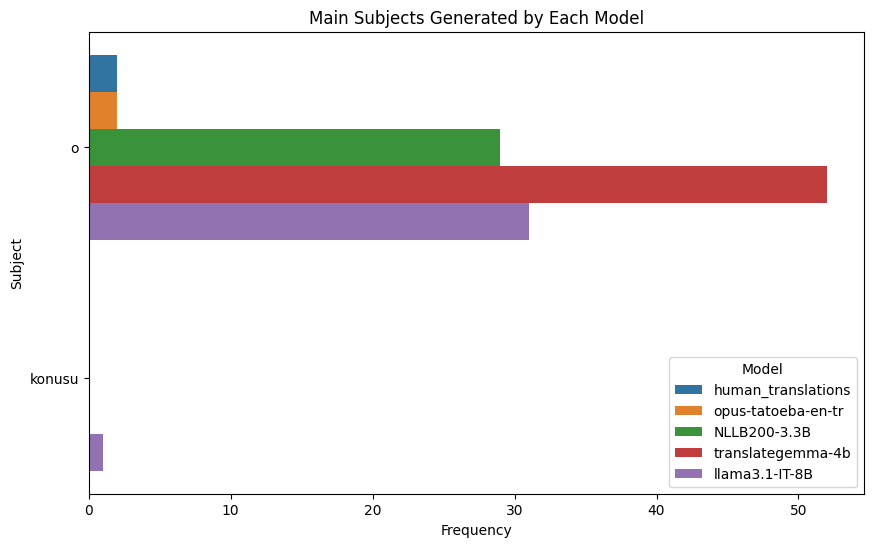

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
# Keep first row per sentence (main subject)
main_subject_df = long_df.groupby(['sentence_id', 'model'], as_index=False).nth(0).reset_index(drop=True)

# Exclude placeholders and "onun" only for plotting
plot_df1 = main_subject_df[~main_subject_df['subject'].isin(["-", "onun", "o'nun"])]

plt.figure(figsize=(10,6))
sns.countplot(data=plot_df1, y="subject", hue="model", 
              palette="tab10")  #https://matplotlib.org/stable/gallery/color/colormap_reference.html)
plt.title("Main Subjects Generated by Each Model")
plt.xlabel("Frequency")
plt.ylabel("Subject")
plt.legend(title="Model")
plt.show()

#### For all genitive subject pronouns of the embbeded clause

In [62]:
long_df_genitive = []

for model in model_cols:
    subj_col = f"subject_pronouns_{model}"
    label_col = f"pronoun_labels_{model}"

    for idx, (subjects, labels) in enumerate(zip(df[subj_col], df[label_col])):

        # parse subject
        if isinstance(subjects, str) and subjects.strip():
            subj_list = [s.strip() for s in subjects.split(",")]
        else:
            subj_list = ["-"]

        # parse labels
        if isinstance(labels, str) and labels.strip():
            label_list = [int(x) for x in labels.split(",")]
        else:
            label_list = [0]

        # use subjects[1] if it exists, else subjects[0]
        if len(label_list) > 1 and label_list[1] == 1:
            subj = subj_list[1] if len(subj_list) > 1 else subj_list[0]
            long_df_genitive.append({
                "model": model,
                "subject": subj,
                "kept": 1,
                "coreference": df.loc[idx, "coreference"],
                "sentence_id": df.loc[idx, "sentence_id"],
                "group_id": df.loc[idx, "group_id"]
            })

        # if only "onun" is present in first position
        elif len(label_list) == 1 and label_list[0] == 1:
            subj = subj_list[0]
            long_df_genitive.append({
                "model": model,
                "subject": subj,
                "kept": 1,
                "coreference": df.loc[idx, "coreference"],
                "sentence_id": df.loc[idx, "sentence_id"],
                "group_id": df.loc[idx, "group_id"]
            })

long_df_genitive = pd.DataFrame(long_df_genitive)
long_df_genitive.to_csv("long_df2_genitive_nmt.csv", index=False)

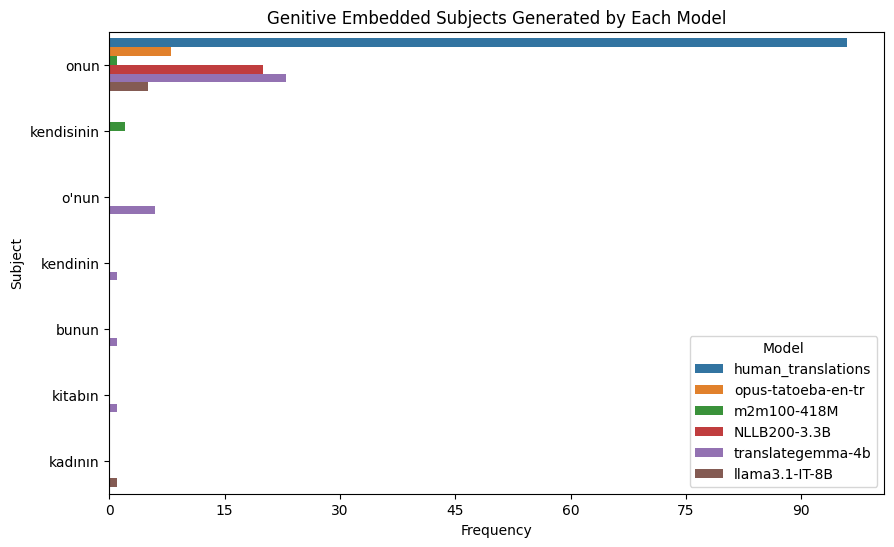

In [63]:
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.pyplot as plt

plot_df2 = long_df_genitive.copy()  # all genitive subjects
plt.figure(figsize=(10,6))
sns.countplot(data=plot_df2, y="subject", hue="model", 
              palette="tab10")  #https://matplotlib.org/stable/gallery/color/colormap_reference.html
plt.title("Genitive Embedded Subjects Generated by Each Model")
plt.xlabel("Frequency")
plt.ylabel("Subject")
plt.legend(title="Model")

# Force integer x-axis ticks
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True)) ## Source - https://stackoverflow.com/a
# Posted by Cédric Van Rompay, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-23, License - CC BY-SA 4.0
plt.show()

After Plotting now, we can look sentences with "kendisinin" closely.

In [58]:
def contains_kendi(text):
    if not isinstance(text, str):
        return False

    doc = nlp(text)
    for sent in doc.sentences:
        for word in sent.words:
            if word.upos == "PRON" and word.feats:
                feats = word.feats.split("|")
                if "Case=Gen" in feats and "Person=3" in feats and any("Reflex=Yes" in f for f in feats): #reflex=yes corresponds "kendi" in Turkish
                    return word.text.lower()
    return False

In [59]:
rows = [] #temporary container to collect data row by row 

for model in model_cols:
    for _, row in df.iterrows():
        kendi_form = contains_kendi(row[model])
        if kendi_form:
            rows.append({
                "model": model,
                "source_sentence": row["source_sentence"],
                "coreference": row["coreference"],
                "translation": row[model]
            })

kendi_df = pd.DataFrame(rows)

In [60]:
kendi_df.head(15)

,model,source_sentence,coreference,translation
0,m2m100-418M,She whispered that she was feeling nervous.,1,Kendisinin sinirlendiğini söylüyordu.
1,m2m100-418M,He promised that she would keep the secret.,0,Kendisinin gizli tuttuğunu söyledi.
2,translategemma-4b,Olivia thought that she deserved another chance.,1,"Olivia, kendisinin tekrar bir şans hak ettiğin..."
3,translategemma-4b,Laura noticed that she was being watched.,1,"Laura, kendisinin izlendiğini fark etti."
4,translategemma-4b,She discovered what she was truly capable of.,1,Kendinin gerçekten neler yapabileceğini keşfetti.
5,llama3.1-IT-8B,Laura noticed that she was being watched.,1,"Laura, kendisinin izleniyor olduğundan fark etti."


In [61]:
for col in model_cols:
    print(f"\n {col}")
    for _, row in df.iterrows():
        tgt = row[col]
        kendi_form = contains_kendi(tgt)
        if kendi_form:
            print("Source:", row["source_sentence"])
            print("Coreference:", row["coreference"])
            print("Target:", tgt)
            print("-" * 40)


 human_translations

 opus-tatoeba-en-tr

 m2m100-418M
Source: She whispered that she was feeling nervous.
Coreference: 1
Target: Kendisinin sinirlendiğini söylüyordu.
----------------------------------------
Source: He promised that she would keep the secret.
Coreference: 0
Target: Kendisinin gizli tuttuğunu söyledi.
----------------------------------------

 NLLB200-3.3B

 translategemma-4b
Source: Olivia thought that she deserved another chance.
Coreference: 1
Target: Olivia, kendisinin tekrar bir şans hak ettiğine inanıyordu.
----------------------------------------
Source: Laura noticed that she was being watched.
Coreference: 1
Target: Laura, kendisinin izlendiğini fark etti.
----------------------------------------
Source: She discovered what she was truly capable of.
Coreference: 1
Target: Kendinin gerçekten neler yapabileceğini keşfetti.
----------------------------------------

 llama3.1-IT-8B
Source: Laura noticed that she was being watched.
Coreference: 1
Target: Laura, ke